# 02 — Feature Engineering

Запускаем `src.features.build_features()` и смотрим:
- какие фичи получились
- насколько они разделяют ботов от нормы
- какие коррелируют между собой (избыточность)


In [1]:
import sys
sys.path.append('..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

from src.features import build_features


In [2]:
feats = build_features()
feats.shape


[features] Загружаю сырые данные...


[features] Профильные...
[features] Активностные...


[features] Технические...


[features] Текстовые (MinHash, может занять минуту)...


[features] Графовые...


[features] Сохранено: C:\Users\evgra.LAPTOP-JGPFUINE\PycharmProjects\first_analytics_antifrod\data\processed\features.csv  shape=(2160, 29)


(2160, 29)

## Сводка по группам

In [3]:
feats.head()


,profile_completeness,has_avatar,account_age_days,n_actions,n_subscribes,n_likes,n_comments_action,n_pyramid_actions,pyramid_action_share,interval_mean,...,ua_entropy,n_comments,n_distinct_texts,duplicate_text_share,mean_text_neighbours,following_count,followers_count,mutual_follow_share,is_bot,bot_cluster_id
user_id,,,,,,,,,,,,,,,,,,,,,
1,0.654,1,484,28,1,19,8,0,0.0,243085.518519,...,-1.442823e-12,8,8,0.0,0.0,13,8,0.0,0,-1
2,0.750,1,883,41,8,26,7,0,0.0,186663.975,...,-1.442823e-12,7,7,0.0,0.0,23,14,0.0,0,-1
3,0.796,1,377,46,5,34,7,0,0.0,165690.511111,...,-1.442823e-12,7,7,0.0,0.0,15,18,0.0,0,-1
4,0.724,1,207,46,3,38,5,0,0.0,167217.711111,...,-1.442823e-12,5,5,0.0,0.0,10,8,0.0,0,-1
5,0.826,1,722,51,4,39,8,0,0.0,147298.96,...,-1.442823e-12,8,8,0.0,0.0,7,15,0.0,0,-1


## Сравнение средних: боты vs норма

In [4]:
bot_mean = feats[feats.is_bot==1].drop(columns=['is_bot','bot_cluster_id']).mean()
norm_mean = feats[feats.is_bot==0].drop(columns=['is_bot','bot_cluster_id']).mean()
cmp = pd.DataFrame({'bot': bot_mean, 'normal': norm_mean})
cmp['ratio'] = cmp['bot'] / cmp['normal'].replace(0, np.nan)
cmp.sort_values('ratio', key=lambda s: s.abs(), ascending=False)


,bot,normal,ratio
ua_entropy,1.549026,-0.0,-1073607630744.532227
mutual_follow_share,0.717709,0.00638,112.492335
duplicate_text_share,1.0,0.015853,63.080648
n_pyramid_actions,5.5125,0.114,48.355263
pyramid_action_share,0.097771,0.002859,34.194882
mean_text_neighbours,89.954301,3.868064,23.255638
interval_cv,6.042477,0.975606,6.193561
n_unique_uas,3.0,1.0,3.0
followers_count,37.01875,13.896,2.663986
n_comments,18.1625,7.874,2.306642


Самые разделяющие фичи (по отклонению ratio от 1):
- `mutual_follow_share` — кольцевые подписки
- `duplicate_text_share` — шаблонные комменты
- `pyramid_action_share` — связь с пирамидами
- `interval_median`, `min_window_5_sec` — бёрсты во времени


## Коррелограмма

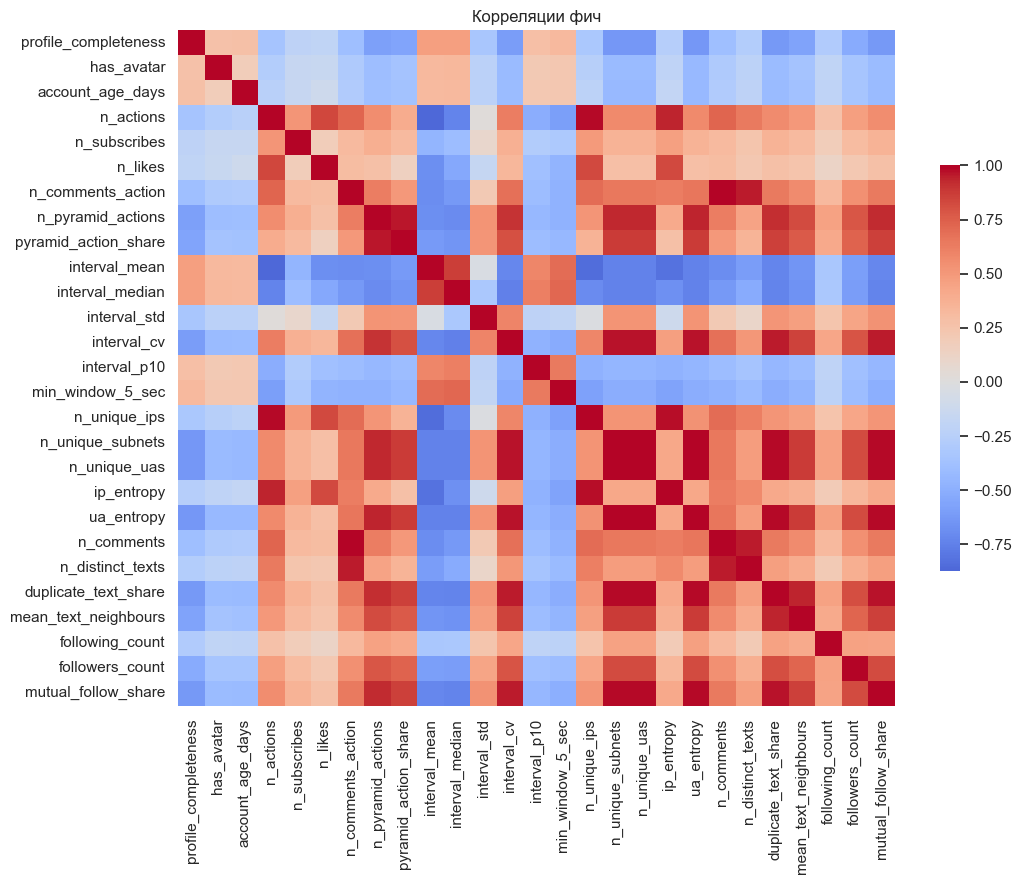

In [5]:
feats_no_truth = feats.drop(columns=['is_bot','bot_cluster_id'])
corr = feats_no_truth.corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax, annot=False, cbar_kws={'shrink':0.6})
ax.set_title('Корреляции фич')
plt.tight_layout(); plt.show()


Сильные корреляции — естественны: `n_comments` коррелирует с `mean_text_neighbours` (больше пишешь — больше совпадений), `n_actions` ~ `n_likes` ~ `n_comments_action`. В DBSCAN мы оставляем только дискриминирующие фичи (см. `DBSCAN_FEATURES`).

## 2D-проекция фич: видны ли фермы?

C:\Users\evgra.LAPTOP-JGPFUINE\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


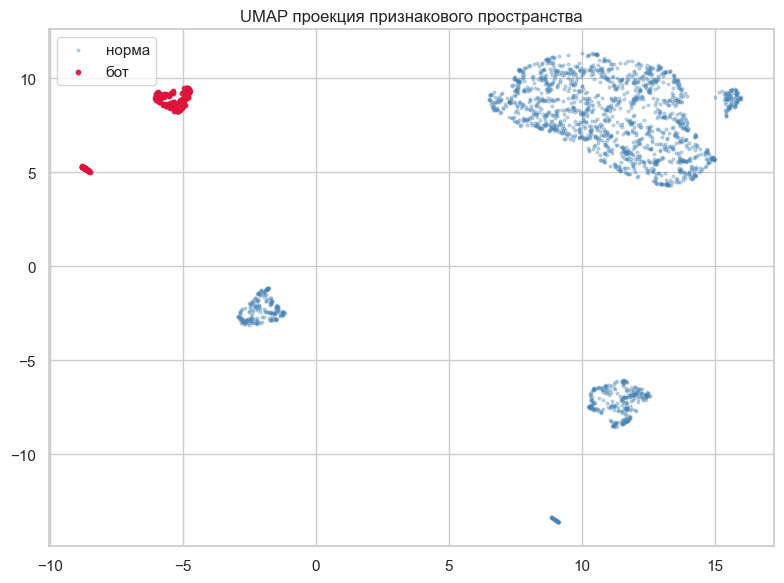

In [6]:
from sklearn.preprocessing import StandardScaler
import umap
from src.detection import DBSCAN_FEATURES, prepare_dbscan_matrix

X, cols = prepare_dbscan_matrix(feats)
embedding = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X)

fig, ax = plt.subplots(figsize=(8,6))
is_bot = feats['is_bot'].values
ax.scatter(embedding[is_bot==0,0], embedding[is_bot==0,1], s=4, alpha=0.3, label='норма', c='steelblue')
ax.scatter(embedding[is_bot==1,0], embedding[is_bot==1,1], s=10, alpha=0.9, label='бот', c='crimson')
ax.set_title('UMAP проекция признакового пространства')
ax.legend()
plt.tight_layout(); plt.show()


На UMAP-проекции боты должны сидеть отдельной структурой (или несколькими) от основной массы. Если фермы хорошо разделены — это будет несколько компактных пятен.

Дальше: `03_detection.ipynb` — кластеризуем.